In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import gropt
from helper_utils import *
import gropt
from gropt_diffusion2 import *
from trap_diffusion3 import *

# note need to name file to specify DWI or DTI cause will de-rate refocusing a little 

In [2]:
def compute_moments(g, dt, T_readout, TE, Nm=3):
    """
    Compute gradient moments M0, M1, M2 with spin-echo inversion.
    """
    GAMMA = 2 * np.pi * 42.577e6  # rad/T/s

    G = g.copy()
    tINV = int(np.floor(TE / dt / 2.0))
    print(tINV)

    INV = np.ones(G.size)
    INV[tINV:] = -1


    tvec = np.arange(G.size) * dt
    tMat = np.array([tvec**mm for mm in range(Nm)])

    mm = GAMMA * dt * tMat * (G * INV)[np.newaxis, :]
    moments = np.cumsum(mm, axis=1)

    return moments

Added M0 = 0
Added M1 = 0
Added M2 = 0
Added M3 = 0
Added M4 = 0
 TE=60.00 ms | Final Good=False | b=694.76 | Solve=5455.42 ms
150


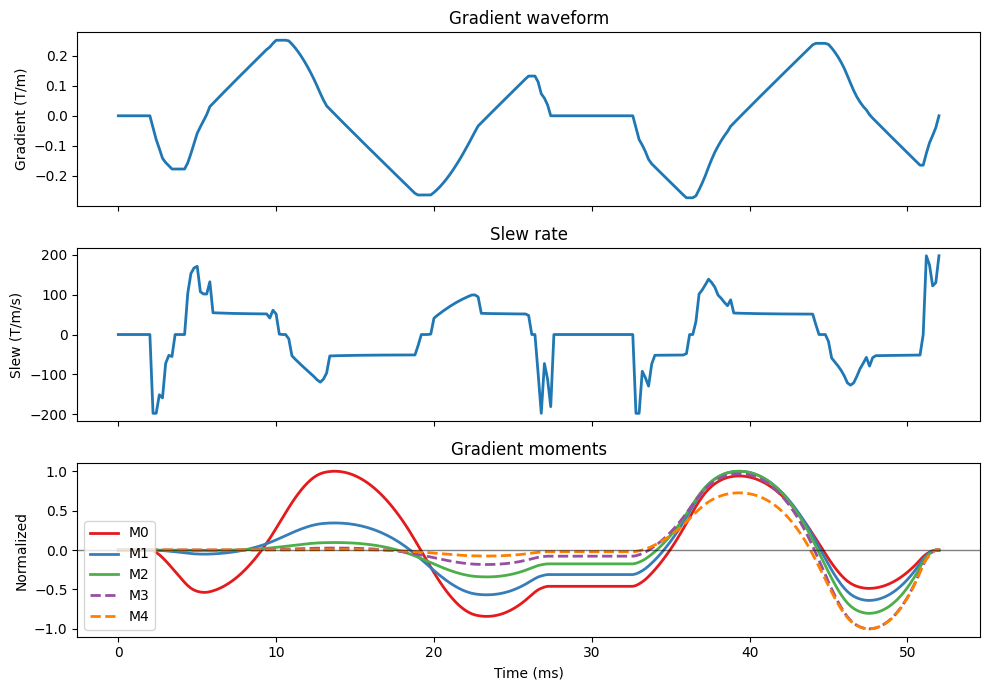

In [16]:
# --- Initialize gradient parameters ---
TE = 60e-3
T_readout = 8e-3
dt = 200e-6
# --- Initiate GrOpt ---
gparams = gropt.GroptParams()
gparams.diff_init(T_90=2e-3, T_180=5e-3, T_readout=T_readout, TE=TE, dt=dt) 

gmax = 0.3
smax= 200
b_target = 400

mmt = 4
pns_Factor = 1
pns_mode = True

# --- Set SAFE ---
if pns_mode:
    asc_file_name = '/Users/ariel/Desktop/MP_GradSys_P034_X60.asc'
    [safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name)
    for ii in range(3):
        gparams.add_SAFE(pns_Factor, safe_params=safe_params, new_first_axis=ii)

    for ii in range(3):
        gparams.add_SAFE(pns_Factor, safe_params=safe_params_cardiac, new_first_axis=ii)
        

# --- Add hardware & b-value constraints ---
gparams.add_gmax(gmax)
gparams.add_smax(smax)

#gparams.add_moment(0, 0.0) # Always enforce zeroth moment (area)

# Optionally enforce higher-order moments
for ii in range(0, mmt+1):
    gparams.add_moment(ii, 0.0)
    print(
        f"Added M{ii} = 0"
    )


gparams.add_bvalue(b_target+1,mode=3) #' 

# Solve waveform
start_t = timer()
solver = gropt.SolverGroptSDMM()
#
solver.set_general_params(min_iter=6000, max_iter=10000, max_feval=100000)

# numb

solver.solve(gparams)
stop_t = timer()

out = gparams.get_out()
final_good = gparams.final_good > 0
bval = gparams.get_output_bvalue()
solve_time_ms = 1000 * (stop_t - start_t)

print(f" TE={TE*1e3:.2f} ms | Final Good={final_good} | b={bval:.2f} | Solve={solve_time_ms:.2f} ms")

from matplotlib import pyplot as plt
import seaborn as sns

# --- Compute moments ---
moments = compute_moments(out, dt, T_readout, TE, Nm=5)

# --- Plot ---
fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

time_ms = np.arange(out.size) * dt * 1e3
cb_colors = sns.color_palette('Set1')
line_styles = ['-', '-', '-', '--', '--']

# Gradient
ax[0].plot(time_ms, out, lw=2)
ax[0].set_ylabel('Gradient (T/m)')
ax[0].set_title('Gradient waveform')

# Slew rate
slew = np.diff(out, prepend=0) / dt
ax[1].plot(time_ms, slew, lw=2)
ax[1].set_ylabel('Slew (T/m/s)')
ax[1].set_title('Slew rate')

# Moments
for order in range(5):
    mmt = moments[order]
    ax[2].plot(
        time_ms,
        mmt / np.max(np.abs(mmt)),
        color=cb_colors[order],
        linestyle=line_styles[order],
        lw=2,
        label=f'M{order}'
    )

ax[2].axhline(0, color='k', lw=1, alpha=0.5)
ax[2].set_ylabel('Normalized')
ax[2].set_xlabel('Time (ms)')
ax[2].set_title('Gradient moments')
ax[2].legend(loc='lower left')

plt.tight_layout()
plt.show()